In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [29]:

data = pd.read_csv("Housing_Price.csv")


In [30]:

# Step 2: Display basic info
print("----- Dataset Information -----")
print(data.info())
print("\n----- First 5 Rows -----")
print(data.head())


----- Dataset Information -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

----- First 5 Rows -----
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000 

In [31]:

# Step 3: Check for missing values
print("\n----- Missing Values -----")
print(data.isnull().sum())



----- Missing Values -----
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [32]:

# Step 4: Statistical summary
print("\n----- Statistical Summary -----")
print(data.describe())



----- Statistical Summary -----
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [33]:

# Step 5: Encode categorical columns
label = LabelEncoder()
for col in ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
            'airconditioning', 'prefarea', 'furnishingstatus']:
    data[col] = label.fit_transform(data[col])


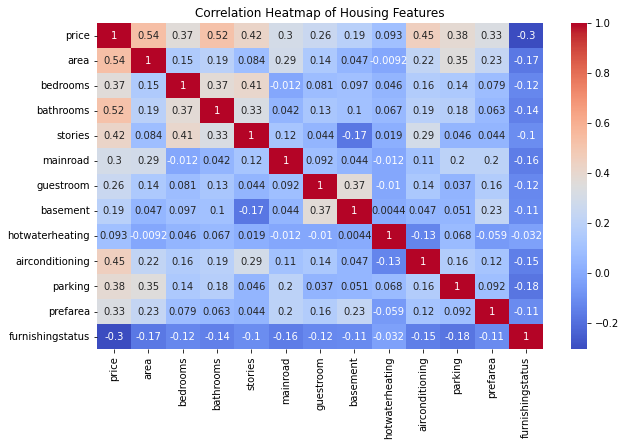

In [36]:

# Step 6: Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Housing Features")
plt.show()


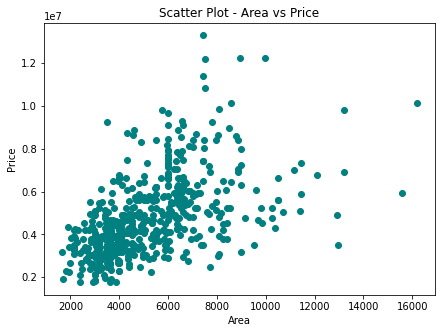

In [37]:

# Step 7: Scatter Plot (area vs price)
plt.figure(figsize=(7,5))
plt.scatter(data['area'], data['price'], color='teal')
plt.title("Scatter Plot - Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()


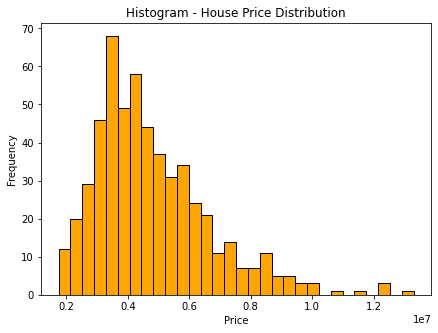

In [38]:

# Step 8: Histogram (Price Distribution)
plt.figure(figsize=(7,5))
plt.hist(data['price'], bins=30, color='orange', edgecolor='black')
plt.title("Histogram - House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


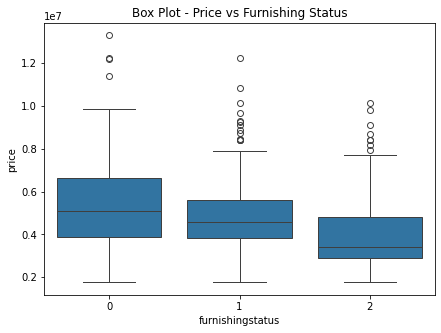

In [39]:

# Step 9: Box Plot (Price vs Furnishing Status)
plt.figure(figsize=(7,5))
sns.boxplot(x='furnishingstatus', y='price', data=data)
plt.title("Box Plot - Price vs Furnishing Status")
plt.show()


In [40]:

# Step 10: Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.drop('price', axis=1))


In [41]:

# Step 11: Apply K-Means for different k values
inertia = []
sil_scores = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))


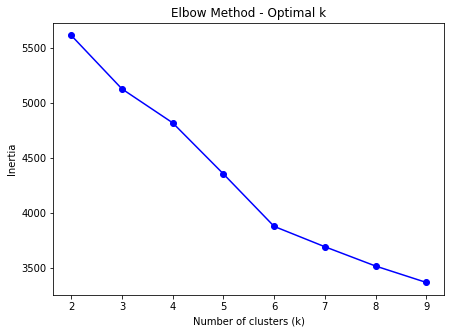

In [42]:

# Step 12: Plot Elbow Graph
plt.figure(figsize=(7,5))
plt.plot(K, inertia, 'bo-')
plt.title("Elbow Method - Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()


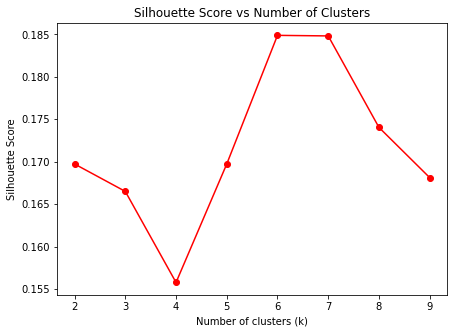

In [43]:

# Step 13: Plot Silhouette Scores
plt.figure(figsize=(7,5))
plt.plot(K, sil_scores, 'ro-')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()


In [44]:

# Step 14: Final KMeans with best k (e.g., k=3)
kmeans_final = KMeans(n_clusters=3, random_state=42)
data['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("\n----- Cluster Centers -----")
print(kmeans_final.cluster_centers_)

print("\n----- Cluster Distribution -----")
print(data['Cluster'].value_counts())



----- Cluster Centers -----
[[ 0.52930768  0.03527706 -0.00608096 -0.36780929  0.27858893  1.24676856
   1.21301259 -0.09236275  0.1968429   0.14008134  0.86552598 -0.28943712]
 [-0.42746871 -0.3824847  -0.47198961 -0.31999167 -0.23124659 -0.44690354
  -0.29911583 -0.0172941  -0.42904333 -0.33941827 -0.29654085  0.28791265]
 [ 0.41614423  0.7070226   0.91035268  0.89486543  0.23103704 -0.09435298
  -0.35217247  0.10370618  0.67300716  0.54436214 -0.09180294 -0.33149188]]

----- Cluster Distribution -----
Cluster
1    284
2    148
0    113
Name: count, dtype: int64


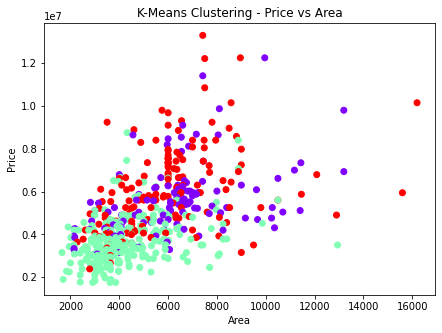

In [45]:

# Step 15: Visualize Clusters (Price vs Area)
plt.figure(figsize=(7,5))
plt.scatter(data['area'], data['price'], c=data['Cluster'], cmap='rainbow')
plt.title("K-Means Clustering - Price vs Area")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()
